# Decay fit voor 3 losse testfiles in één notebook

Deze notebook laat **drie decay-testbestanden afzonderlijk door exact dezelfde workflow lopen** en zet de uitkomsten samen in één notebook.

De workflow per bestand is:

1. experimentdata inlezen uit `.h5m`
2. equilibrium en initiële amplitude bepalen
3. decay-start bepalen uit het gefilterde signaal
4. referentie-extrema uit experiment bepalen
5. OrcaFlex grid search uitvoeren
6. beste simulatie opnieuw draaien
7. vergelijking, periode en RMSE samenvatten

Pas vooral de paden aan in de configuratiecel hieronder.


In [1]:

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import h5py
import OrcFxAPI

from pathlib import Path
from scipy.signal import find_peaks

plt.rcParams["figure.figsize"] = (11, 5)
plt.rcParams["axes.grid"] = True

# =========================
# Algemene instellingen
# =========================
MODEL_PATH = r"c:\Users\verav\Desktop\Studie\Afstuderen\PHASE2_ORCA\Decay_opzet_spring_fine_V5.dat"


EXP_PATHS = [
    r"C:\Users\verav\Desktop\Studie\Afstuderen\Decay_Data\01_Rawdata\02\002\34224_03CB_02_002_001_01_Decay1.h5m",
    r"C:\Users\verav\Desktop\Studie\Afstuderen\Decay_Data\01_Rawdata\02\002\34224_03CB_02_002_001_01_Decay2.h5m",
    r"C:\Users\verav\Desktop\Studie\Afstuderen\Decay_Data\01_Rawdata\02\002\34224_03CB_02_002_001_01_Decay3.h5m",
]

TITLE_SIZE = 18
LABEL_SIZE = 14
TICK_SIZE = 12

N_EXTREMA = 6

LOOKBACK_WINDOW = 5.0
QUIET_WINDOW_END = 12.0
QUIET_WINDOW_LENGTH = 50.0

# Coarse grid
LIN_VALUES_COARSE = np.linspace(0, 1000, 5)
QUAD_VALUES_COARSE = np.linspace(0, 1000, 5)

# Refined grid rondom coarse optimum
DELTA_LIN = 200
DELTA_QUAD = 200
N_REFINED = 5

# OrcaFlex objectnamen
CONSTRAINT_NAME = "decay_constraint"
FLOATER_NAME = "floaters"
FLOATERTYPE_NAME = "Floatertype"

# Te gebruiken signalen uit het .h5m-bestand
FILTERED_TIME_KEY = "FittedSignals/time"
FILTERED_SIGNAL_KEY = "FittedSignals/PITCH decay fit"
UNFILTERED_TIME_KEY = "UnfilteredSignals/time"
UNFILTERED_SIGNAL_KEY = "UnfilteredSignals/PITCH (unfiltered)"


In [2]:

def load_experiment_data(exp_path):
    with h5py.File(exp_path, "r") as f:
        t_filt = f[FILTERED_TIME_KEY][:]
        z_filt = f[FILTERED_SIGNAL_KEY][:]
        t_unfiltered = f[UNFILTERED_TIME_KEY][:]
        z_unfiltered = f[UNFILTERED_SIGNAL_KEY][:]
    return t_filt, z_filt, t_unfiltered, z_unfiltered


def shift_signal_to_first_extremum_after_start(t, z, positive=True, prominence=None):
    t = np.asarray(t)
    z = np.asarray(z)

    if len(t) < 2:
        raise ValueError("Signaal is te kort.")

    t_rest = t[1:]
    z_rest = z[1:]

    peak_kwargs = {}
    if prominence is not None:
        peak_kwargs["prominence"] = prominence

    if positive:
        idx_local, _ = find_peaks(z_rest, **peak_kwargs)
    else:
        idx_local, _ = find_peaks(-z_rest, **peak_kwargs)

    if len(idx_local) == 0:
        raise ValueError("Geen overeenkomstig extremum gevonden na initiële amplitude.")

    idx_first = idx_local[0] + 1
    t_shift = t[idx_first:] - t[idx_first]
    z_shift = z[idx_first:]

    return t_shift, z_shift, idx_first


def get_n_extrema_including_start(t, z, n=8, positive=True, prominence=None):
    t = np.asarray(t)
    z = np.asarray(z)

    if len(t) == 0:
        raise ValueError("Leeg signaal.")
    if n < 1:
        raise ValueError("n moet minstens 1 zijn.")

    t_ext = [t[0]]
    z_ext = [z[0]]

    if n == 1:
        return np.array(t_ext), np.array(z_ext)

    t_rest = t[1:]
    z_rest = z[1:]

    peak_kwargs = {}
    if prominence is not None:
        peak_kwargs["prominence"] = prominence

    if positive:
        idx, _ = find_peaks(z_rest, **peak_kwargs)
    else:
        idx, _ = find_peaks(-z_rest, **peak_kwargs)

    if len(idx) < n - 1:
        raise ValueError(f"Te weinig extrema gevonden: {len(idx)+1} incl. start, {n} nodig.")

    idx = idx[:n-1]
    t_ext.extend(t_rest[idx])
    z_ext.extend(z_rest[idx])

    return np.array(t_ext), np.array(z_ext)


def compute_extrema_rmse_z(z_sim_ext, z_exp_ext):
    z_sim_ext = np.asarray(z_sim_ext)
    z_exp_ext = np.asarray(z_exp_ext)

    if len(z_sim_ext) != len(z_exp_ext):
        raise ValueError("Lengtes van z-extrema komen niet overeen.")

    scale = max(np.mean(np.abs(z_exp_ext)), 1e-6)
    nrmse_z = np.sqrt(np.mean(((z_sim_ext - z_exp_ext) / scale) ** 2))
    return nrmse_z


def compute_period(signal_t, signal_z, positive=True, prominence=0.01):
    if positive:
        idx, _ = find_peaks(signal_z, prominence=prominence)
    else:
        idx, _ = find_peaks(-signal_z, prominence=prominence)

    if len(idx) < 2:
        return np.nan, idx

    periods = np.diff(signal_t[idx])
    return np.mean(periods), idx


In [3]:

def prepare_experiment_case(exp_path,
                            lookback_window=LOOKBACK_WINDOW,
                            quiet_window_end=QUIET_WINDOW_END,
                            quiet_window_length=QUIET_WINDOW_LENGTH,
                            n_extrema=N_EXTREMA):
    t_filt, z_filt, t_unfiltered, z_unfiltered = load_experiment_data(exp_path)

    # 1. decay-start referentie uit filtered signal
    t_decay_start_guess = t_filt[0]

    # 2. rustige periode in ongefilterd signaal
    quiet_start = t_decay_start_guess - quiet_window_end - quiet_window_length
    quiet_end = t_decay_start_guess - quiet_window_end
    mask_quiet = (t_unfiltered >= quiet_start) & (t_unfiltered <= quiet_end)

    if not np.any(mask_quiet):
        raise ValueError("Geen data gevonden in de gekozen rustige periode.")

    z_eq = np.mean(z_unfiltered[mask_quiet])

    # 3. initiële amplitude zoeken in ongefilterd signaal
    search_start = t_decay_start_guess - lookback_window
    search_end = t_decay_start_guess
    mask_search = (t_unfiltered >= search_start) & (t_unfiltered <= search_end)

    if not np.any(mask_search):
        raise ValueError("Geen data gevonden in zoekvenster vóór decay-start.")

    t_search = t_unfiltered[mask_search]
    z_search = z_unfiltered[mask_search]

    deviation = z_search - z_eq
    idx_local = np.argmax(np.abs(deviation))

    t_init = t_search[idx_local]
    z_init = z_search[idx_local]
    A0_signed = z_init - z_eq
    A0 = np.abs(A0_signed)

    # 4. eerste piek in gefilterd signaal na t_init
    mask_after_init = t_filt > t_init
    t_after = t_filt[mask_after_init]
    z_after = z_filt[mask_after_init]

    if len(t_after) == 0:
        raise ValueError("Geen gefilterde data gevonden na t_init.")

    if A0_signed >= 0:
        peaks, _ = find_peaks(z_after)
    else:
        peaks, _ = find_peaks(-z_after)

    if len(peaks) == 0:
        raise ValueError("Geen pieken gevonden in gefilterde signaal na t_init.")

    idx_first_peak_local = peaks[0]
    t_decay_start = t_after[idx_first_peak_local]
    z_decay_start = z_after[idx_first_peak_local]

    # 5. decay-signaal maken vanaf eerste piek
    mask_decay = t_filt >= t_decay_start
    t_decay = t_filt[mask_decay] - t_decay_start
    z_decay = z_filt[mask_decay] - z_eq
    z_decay = z_decay - np.mean(z_decay)

    fit_positive = A0_signed >= 0
    prom = 0.01 * abs(z_decay[0]) if abs(z_decay[0]) > 0 else None

    t_ref, z_ref = get_n_extrema_including_start(
        t_decay,
        z_decay,
        n=n_extrema,
        positive=fit_positive,
        prominence=prom
    )

    return {
        "exp_path": exp_path,
        "case_name": Path(exp_path).stem,
        "t_filt": t_filt,
        "z_filt": z_filt,
        "t_unfiltered": t_unfiltered,
        "z_unfiltered": z_unfiltered,
        "t_decay_start_guess": t_decay_start_guess,
        "quiet_start": quiet_start,
        "quiet_end": quiet_end,
        "z_eq": z_eq,
        "search_start": search_start,
        "search_end": search_end,
        "t_init": t_init,
        "z_init": z_init,
        "A0": A0,
        "A0_signed": A0_signed,
        "t_decay_start": t_decay_start,
        "z_decay_start": z_decay_start,
        "t_decay": t_decay,
        "z_decay": z_decay,
        "fit_positive": fit_positive,
        "prom": prom,
        "t_ref": t_ref,
        "z_ref": z_ref,
    }


In [4]:

def plot_experiment_case(case):
    plt.figure(figsize=(11, 5))
    plt.plot(case["t_filt"], case["z_filt"], label="Filtered signal")
    plt.plot(case["t_unfiltered"], case["z_unfiltered"], ":", label="Unfiltered signal")
    plt.axhline(case["z_eq"], linestyle="--", label="Equilibrium level")
    plt.axvline(case["t_init"], linestyle="--", label="Initial amplitude (unfiltered)")
    plt.axvline(case["t_decay_start"], linestyle="--", label="Decay start (first filtered peak)")
    plt.scatter([case["t_init"]], [case["z_init"]], zorder=5)
    plt.scatter([case["t_decay_start"]], [case["z_decay_start"]], zorder=5)
    plt.xlabel("Time [s]")
    plt.ylabel("Pitch [deg]")
    plt.title(f'Experiment analyse - {case["case_name"]}', fontsize=TITLE_SIZE)
    plt.legend(fontsize=10)
    plt.show()

    print(f'Case                        = {case["case_name"]}')
    print(f'Decay start guess (cropped) = {case["t_decay_start_guess"]:.3f} s')
    print(f'Quiet window                = [{case["quiet_start"]:.3f}, {case["quiet_end"]:.3f}] s')
    print(f'Equilibrium level z_eq      = {case["z_eq"]:.6f} degree')
    print(f'Search window               = [{case["search_start"]:.3f}, {case["search_end"]:.3f}] s')
    print(f'Initial extreme (unfilt) t  = {case["t_init"]:.3f} s')
    print(f'Initial extreme (unfilt) z  = {case["z_init"]:.6f} degree')
    print(f'Initial amplitude A0        = {case["A0"]:.6f} degree')
    print(f'Signed amplitude            = {case["A0_signed"]:.6f} degree')
    print(f'Decay start (filtered peak) = {case["t_decay_start"]:.3f} s')
    print(f'Decay start z               = {case["z_decay_start"]:.6f} degree')

    print("\nReferentie-extrema uit experiment:")
    kind = "top" if case["fit_positive"] else "dal"
    for i, (tt, zz) in enumerate(zip(case["t_ref"], case["z_ref"]), start=1):
        print(f"{kind} {i}: t = {tt:.4f} s, z = {zz:.6f} deg")


In [5]:

def run_decay_simulation(c_lin, c_quad, A0_signed, model_path=MODEL_PATH):
    model = OrcFxAPI.Model(model_path)
    constraint = model[CONSTRAINT_NAME]
    floaters = model[FLOATER_NAME]
    floatertype = model[FLOATERTYPE_NAME]

    floatertype.OtherDampingLinearCoeffRy = c_lin
    floatertype.OtherDampingQuadraticCoeffRy = c_quad

    # Pas dit aan als jouw beginvoorwaarde op een andere manier wordt gezet
    floaters.InitialTrim = A0_signed

    model.RunSimulation()

    t_sim = np.array(model.general.TimeHistory("Time"))
    z_sim_raw = np.array(floaters.TimeHistory("Rotation 2"))

    n_tail = min(100, len(z_sim_raw))
    z_eq_sim = np.mean(z_sim_raw[-n_tail:])
    z_sim = z_sim_raw - z_eq_sim
    t_sim = t_sim - t_sim[0]

    return t_sim, z_sim


def run_grid_search(case, lin_values, quad_values, model_path=MODEL_PATH, verbose=True):
    results = []
    best_score = np.inf
    best = None

    for c_lin in lin_values:
        for c_quad in quad_values:
            try:
                t_sim, z_sim = run_decay_simulation(c_lin, c_quad, case["A0_signed"], model_path)

                t_sim_shift, z_sim_shift, _ = shift_signal_to_first_extremum_after_start(
                    t_sim,
                    z_sim,
                    positive=case["fit_positive"],
                    prominence=case["prom"]
                )

                t_sim_ext, z_sim_ext = get_n_extrema_including_start(
                    t_sim_shift,
                    z_sim_shift,
                    n=N_EXTREMA,
                    positive=case["fit_positive"],
                    prominence=case["prom"]
                )

                score = compute_extrema_rmse_z(z_sim_ext, case["z_ref"])
                results.append((c_lin, c_quad, score))

                if verbose:
                    print(f'[{case["case_name"]}] lin={c_lin:.3f}, quad={c_quad:.3f}, score={score:.6f}')

                if np.isfinite(score) and score < best_score:
                    best_score = score
                    best = (c_lin, c_quad)

            except Exception as e:
                if verbose:
                    print(f'[{case["case_name"]}] FOUT bij lin={c_lin:.3f}, quad={c_quad:.3f}: {e}')
                results.append((c_lin, c_quad, np.nan))

    return best, best_score, results


In [6]:

def run_full_case(exp_path, model_path=MODEL_PATH, verbose=True, show_plots=True):
    case = prepare_experiment_case(exp_path)

    z_decay = case["z_decay"]
    t_decay = case["t_decay"]
    prom = case["prom"]

    peaks, _ = find_peaks(z_decay, prominence=prom)
    troughs, _ = find_peaks(-z_decay, prominence=prom)

    z_peaks = z_decay[peaks]
    z_troughs = z_decay[troughs]

    n = min(len(z_peaks), len(z_troughs))
    mid_cycle = 0.5 * (z_peaks[:n] + z_troughs[:n])
    amp_cycle = 0.5 * (z_peaks[:n] - z_troughs[:n])

    print("mid_cycle:", mid_cycle)
    print("gemiddelde middenlijn:", np.mean(mid_cycle))
    print("amp_cycle:", amp_cycle)


    if show_plots:
        plot_experiment_case(case)

    # coarse search
    best_coarse, score_coarse, results_coarse = run_grid_search(
        case,
        LIN_VALUES_COARSE,
        QUAD_VALUES_COARSE,
        model_path=model_path,
        verbose=verbose
    )

    if best_coarse is None:
        raise RuntimeError(f'Geen geldige coarse-best combinatie gevonden voor {case["case_name"]}.')

    best_lin_coarse, best_quad_coarse = best_coarse
    print(f'\n[{case["case_name"]}] Coarse best: lin={best_lin_coarse:.3f}, quad={best_quad_coarse:.3f}, score={score_coarse:.6f}')

    # refined search
    lin_min = max(0, best_lin_coarse - DELTA_LIN)
    lin_max = best_lin_coarse + DELTA_LIN
    quad_min = max(0, best_quad_coarse - DELTA_QUAD)
    quad_max = best_quad_coarse + DELTA_QUAD

    lin_values_refined = np.linspace(lin_min, lin_max, N_REFINED)
    quad_values_refined = np.linspace(quad_min, quad_max, N_REFINED)

    best_refined, score_refined, results_refined = run_grid_search(
        case,
        lin_values_refined,
        quad_values_refined,
        model_path=model_path,
        verbose=verbose
    )

    if best_refined is None:
        raise RuntimeError(f'Geen geldige refined-best combinatie gevonden voor {case["case_name"]}.')

    best_lin, best_quad = best_refined
    print(f'[{case["case_name"]}] Refined best: lin={best_lin:.4f}, quad={best_quad:.4f}, score={score_refined:.6f}')

    # beste simulatie opnieuw draaien
    t_sim, z_sim = run_decay_simulation(best_lin, best_quad, case["A0_signed"], model_path)

    t_sim_shift, z_sim_shift, _ = shift_signal_to_first_extremum_after_start(
        t_sim,
        z_sim,
        positive=case["fit_positive"],
        prominence=case["prom"]
    )

    t_sim_ext, z_sim_ext = get_n_extrema_including_start(
        t_sim_shift,
        z_sim_shift,
        n=N_EXTREMA,
        positive=case["fit_positive"],
        prominence=case["prom"]
    )

    rmse = compute_extrema_rmse_z(z_sim_ext, case["z_ref"])

    T_exp, idx_exp = compute_period(
        case["t_decay"],
        case["z_decay"],
        positive=case["fit_positive"],
        prominence=case["prom"]
    )

    T_sim, idx_sim = compute_period(
        t_sim_shift,
        z_sim_shift,
        positive=case["fit_positive"],
        prominence=case["prom"]
    )

    if show_plots:
        plt.figure(figsize=(11, 5))
        plt.plot(case["t_decay"], case["z_decay"], label="Experiment")
        plt.plot(t_sim_shift, z_sim_shift, label="Simulatie best fit")
        plt.scatter(case["t_ref"], case["z_ref"], label="Exp extrema")
        plt.scatter(t_sim_ext, z_sim_ext, label="Sim extrema")
        plt.xlabel("Time [s]")
        plt.ylabel("Pitch [deg]")
        plt.title(f'Best fit vergelijking - {case["case_name"]}', fontsize=TITLE_SIZE)
        plt.legend(fontsize=10)
        plt.show()

    df_summary = pd.DataFrame({
        "Grootheid": [
            "Linear damping coefficient",
            "Quadratic damping coefficient",
            "Initial amplitude",
            "Period experiment [s]",
            "Period simulation [s]",
            "RMSE",
        ],
        "Waarde": [
            best_lin,
            best_quad,
            case["A0_signed"],
            T_exp,
            T_sim,
            rmse,
        ]
    })

    display(df_summary)

    result = {
        "case_name": case["case_name"],
        "exp_path": exp_path,
        "best_lin": best_lin,
        "best_quad": best_quad,
        "A0_signed": case["A0_signed"],
        "T_exp": T_exp,
        "T_sim": T_sim,
        "rmse": rmse,
        "score_coarse": score_coarse,
        "score_refined": score_refined,
        "case": case,
        "t_sim_shift": t_sim_shift,
        "z_sim_shift": z_sim_shift,
        "t_sim_ext": t_sim_ext,
        "z_sim_ext": z_sim_ext,
        "results_coarse": results_coarse,
        "results_refined": results_refined,
        "df_summary": df_summary,
    }
    return result


## Alle drie decay-files afzonderlijk draaien

De cel hieronder draait het volledige proces voor iedere file in `EXP_PATHS`.


CASE 1: 34224_03CB_02_002_001_01_Decay1.h5m
mid_cycle: [0.15451288 0.11724687 0.09096014 0.07142305 0.05699432 0.04545426
 0.03669834 0.02933478 0.02363724]
gemiddelde middenlijn: 0.06958465
amp_cycle: [4.322669  3.7193096 3.2413807 2.8549569 2.5355597 2.2682908 2.0409665
 1.8460674 1.6768887]


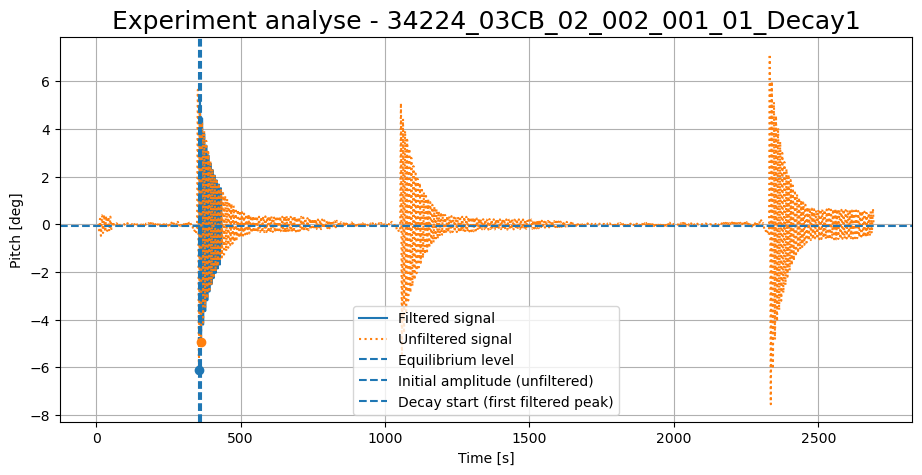

Case                        = 34224_03CB_02_002_001_01_Decay1
Decay start guess (cropped) = 357.116 s
Quiet window                = [295.116, 345.116] s
Equilibrium level z_eq      = -0.055629 degree
Search window               = [352.116, 357.116] s
Initial extreme (unfilt) t  = 355.368 s
Initial extreme (unfilt) z  = -6.104080 degree
Initial amplitude A0        = 6.048451 degree
Signed amplitude            = -6.048451 degree
Decay start (filtered peak) = 362.673 s
Decay start z               = -4.936140 degree

Referentie-extrema uit experiment:
dal 1: t = 0.0000 s, z = -4.899759 deg
dal 2: t = 7.2153 s, z = -4.168156 deg
dal 3: t = 14.4755 s, z = -3.602063 deg
dal 4: t = 21.6909 s, z = -3.150421 deg
dal 5: t = 28.9511 s, z = -2.783534 deg
dal 6: t = 36.1664 s, z = -2.478565 deg
[34224_03CB_02_002_001_01_Decay1] lin=0.000, quad=0.000, score=0.794253
[34224_03CB_02_002_001_01_Decay1] lin=0.000, quad=250.000, score=0.752993
[34224_03CB_02_002_001_01_Decay1] lin=0.000, quad=500.000, sco

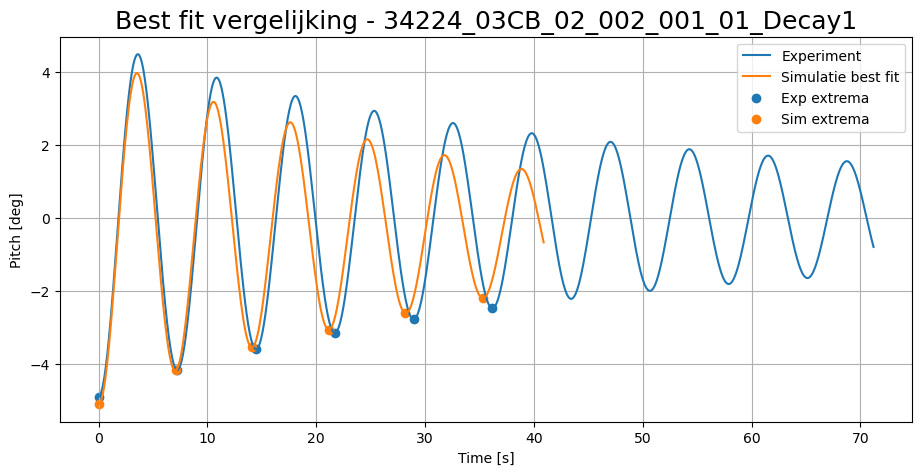

,Grootheid,Waarde
0,Linear damping coefficient,500.000000
1,Quadratic damping coefficient,0.000000
2,Initial amplitude,-6.048451
3,Period experiment [s],7.243393
4,Period simulation [s],7.050000
5,RMSE,0.046172


CASE 2: 34224_03CB_02_002_001_01_Decay2.h5m
mid_cycle: [0.13960326 0.10618329 0.08260727 0.06482172 0.05171847 0.04120076
 0.03319865 0.0264613  0.02123278]
gemiddelde middenlijn: 0.063003056
amp_cycle: [3.947658  3.39907   2.9630919 2.609609  2.317109  2.0715823 1.8629501
 1.6834376 1.528023 ]


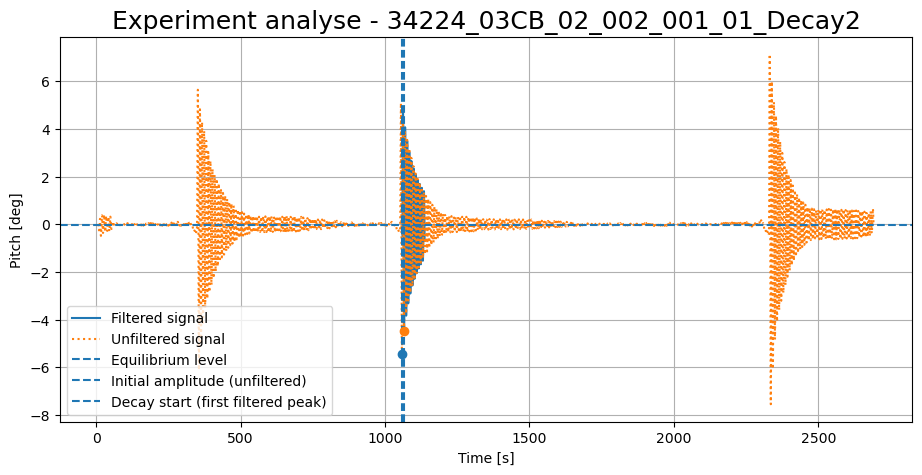

Case                        = 34224_03CB_02_002_001_01_Decay2
Decay start guess (cropped) = 1060.209 s
Quiet window                = [998.209, 1048.209] s
Equilibrium level z_eq      = -0.042893 degree
Search window               = [1055.209, 1060.209] s
Initial extreme (unfilt) t  = 1058.416 s
Initial extreme (unfilt) z  = -5.450894 degree
Initial amplitude A0        = 5.408001 degree
Signed amplitude            = -5.408001 degree
Decay start (filtered peak) = 1065.721 s
Decay start z               = -4.493745 degree

Referentie-extrema uit experiment:
dal 1: t = 0.0000 s, z = -4.471256 deg
dal 2: t = 7.2157 s, z = -3.808055 deg
dal 3: t = 14.4763 s, z = -3.292887 deg
dal 4: t = 21.7369 s, z = -2.880485 deg
dal 5: t = 28.9527 s, z = -2.544787 deg
dal 6: t = 36.2133 s, z = -2.265391 deg
[34224_03CB_02_002_001_01_Decay2] lin=0.000, quad=0.000, score=0.780700
[34224_03CB_02_002_001_01_Decay2] lin=0.000, quad=250.000, score=0.742902
[34224_03CB_02_002_001_01_Decay2] lin=0.000, quad=500.00

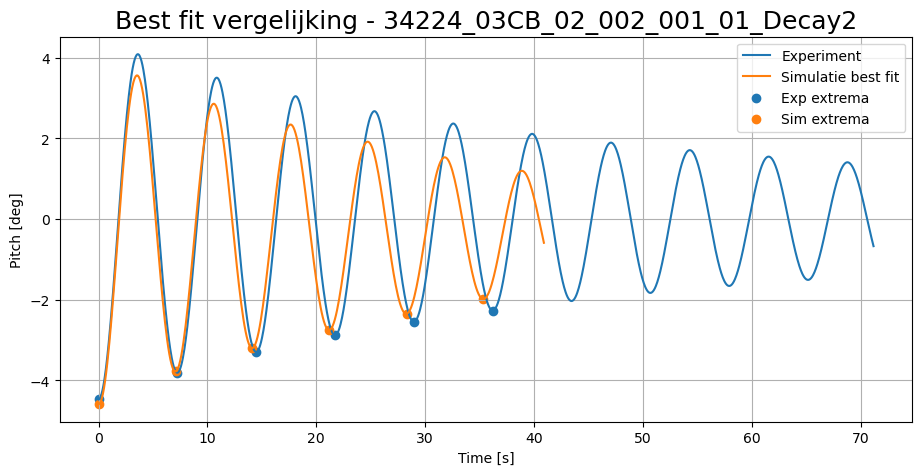

,Grootheid,Waarde
0,Linear damping coefficient,500.000000
1,Quadratic damping coefficient,0.000000
2,Initial amplitude,-5.408001
3,Period experiment [s],7.243787
4,Period simulation [s],7.050000
5,RMSE,0.051139


CASE 3: 34224_03CB_02_002_001_01_Decay3.h5m
mid_cycle: [0.22021079 0.1576314  0.11622894 0.08828568 0.06791615 0.05295801
 0.04150188 0.03255391 0.02549982]
gemiddelde middenlijn: 0.08919851
amp_cycle: [5.1431103 4.322228  3.705604  3.2266889 2.843201  2.5303493 2.2696404
 2.0499454 1.8617713]


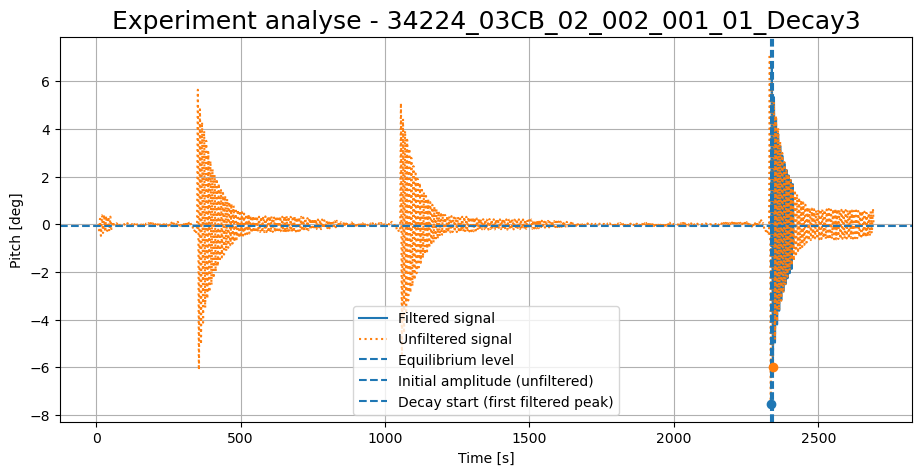

Case                        = 34224_03CB_02_002_001_01_Decay3
Decay start guess (cropped) = 2337.209 s
Quiet window                = [2275.209, 2325.209] s
Equilibrium level z_eq      = -0.057826 degree
Search window               = [2332.209, 2337.209] s
Initial extreme (unfilt) t  = 2335.461 s
Initial extreme (unfilt) z  = -7.544148 degree
Initial amplitude A0        = 7.486322 degree
Signed amplitude            = -7.486322 degree
Decay start (filtered peak) = 2342.766 s
Decay start z               = -6.002034 degree

Referentie-extrema uit experiment:
dal 1: t = 0.0000 s, z = -5.965855 deg
dal 2: t = 7.2161 s, z = -4.922900 deg
dal 3: t = 14.4771 s, z = -4.164597 deg
dal 4: t = 21.6932 s, z = -3.589375 deg
dal 5: t = 28.9541 s, z = -3.138403 deg
dal 6: t = 36.1702 s, z = -2.775285 deg
[34224_03CB_02_002_001_01_Decay3] lin=0.000, quad=0.000, score=0.846956
[34224_03CB_02_002_001_01_Decay3] lin=0.000, quad=250.000, score=0.798371
[34224_03CB_02_002_001_01_Decay3] lin=0.000, quad=500.0

In [ ]:

from unittest import case


all_results = []

for i, exp_path in enumerate(EXP_PATHS, start=1):
    print("=" * 100)
    print(f"CASE {i}: {Path(exp_path).name}")
    print("=" * 100)

    result = run_full_case(
        exp_path=exp_path,
        model_path=MODEL_PATH,
        verbose=True,
        show_plots=True
    )
    all_results.append(result)



## Gezamenlijke samenvatting van de 3 cases

In [ ]:

df_all_summary = pd.DataFrame([
    {
        "case_name": r["case_name"],
        "exp_path": r["exp_path"],
        "best_lin": r["best_lin"],
        "best_quad": r["best_quad"],
        "A0_signed": r["A0_signed"],
        "T_exp": r["T_exp"],
        "T_sim": r["T_sim"],
        "rmse": r["rmse"],
        "score_coarse": r["score_coarse"],
        "score_refined": r["score_refined"],
    }
    for r in all_results
])

df_all_summary


In [ ]:

plt.figure(figsize=(11, 5))

for r in all_results:
    plt.plot(r["case"]["t_decay"], r["case"]["z_decay"], label=f'Exp - {r["case_name"]}')
    plt.plot(r["t_sim_shift"], r["z_sim_shift"], linestyle="--", label=f'Sim - {r["case_name"]}')

plt.xlabel("Time [s]")
plt.ylabel("Pitch [deg]")
plt.title("Vergelijking van alle 3 decay-cases", fontsize=TITLE_SIZE)
plt.legend(fontsize=9, ncol=2)
plt.show()


In [ ]:

# Optioneel: exporteer de gezamenlijke samenvatting
# output_csv = Path.cwd() / "decay_summary_3cases.csv"
# df_all_summary.to_csv(output_csv, index=False)
# print(f"CSV opgeslagen naar: {output_csv}")
